In [ ]:
!pip install --upgrade transformers accelerate peft trl bitsandbytes datasets tqdm pandas matplotlib

# Setup & Configuration

In [1]:
import os
os.environ["HF_HOME"] = "/workspace/huggingface_cache"

import json
import torch
import re
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, BitsAndBytesConfig
from peft import PeftModel
from trl import DPOTrainer, DPOConfig
from tqdm.notebook import tqdm

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# --- CONFIGURATION ---
BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
SFT_ADAPTER_PATH = "/workspace/qwen-chart-sft-final" 
CACHE_FILE = "grounding_cache.json"
TRAIN_FILES = ["train_wo_spec.json"] 
PREFERENCE_DATASET_PATH = "dpo_preference_data.json"

CUDA Available: True
GPU: NVIDIA GeForce RTX 5090


# Prompt Formatting & Scoring Logic

In [2]:
MAX_DESC_WORDS = 50

def format_prompt(row):
    desc = row.get('title_description', '')
    if desc:
        words = desc.split()
        if len(words) > MAX_DESC_WORDS:
            desc = " ".join(words[:MAX_DESC_WORDS]) + "..."
            
    title_block = f"Chart Description:\n{desc}\n\n" if desc else ""
    user_content = (
        f"{title_block}"
        f"Claim: {row['claim']}\n\n"
        f"Data Table:\n{row['table']}\n\n"
        f"Visual Spec:\n{row['spec']}\n\n"
        f"Verify if the claim is supported by the chart data. "
        f"Think through the evidence first, then state your verdict."
    )   # ← single closing paren
    return user_content

In [3]:
# ================================
# 🔥 Hybrid DPO + Causal Reward (V4 - SOTA Alignment)
# ================================

import torch
import re
import json
import matplotlib.colors as mcolors

# --- Helpers ---
STOPWORDS = {'the','a','an','is','are','was','were','in','on','at','to',
             'of','and','or','but','it','this','that','chart','shows',
             'show','data','graph','figure','plot','table','value','values',
             'by','with','from','as','be','has','have','its','for','not'}

COMMON_HEX = {
    "#ff0000": "red", "#00ff00": "green", "#0000ff": "blue",
    "#000000": "black", "#ffffff": "white", "#ffff00": "yellow",
    "#ffa500": "orange", "#800080": "purple", "#808080": "gray",
    "#00ffff": "cyan", "#ff00ff": "magenta"
}

def hex_to_name(hex_code):
    hex_code = hex_code.lower()
    if hex_code in COMMON_HEX: return COMMON_HEX[hex_code]
    try:
        reverse_colors = {v.lower(): k for k, v in mcolors.CSS4_COLORS.items()}
        if hex_code in reverse_colors: return reverse_colors[hex_code]
    except: pass
    return None

def extract_meaningful_numbers(text):
    all_nums = list(map(float, re.findall(r'[-+]?\d*\.?\d+', text)))
    return [n for n in all_nums
            if not (1950 <= n <= 2030)         
            and not (n == int(n) and n < 10)   
            and n != 0]

def extract_verdict(text):
    tl = text.strip().lower()
    matches = re.findall(r'verdict:\s*(supported|true|refuted|false)', tl)
    if matches: return 1 if matches[-1] in ('supported', 'true') else 0
    if re.match(r'the claim is (true|correct|supported)', tl): return 1
    if re.match(r'the claim is (false|incorrect|wrong)', tl):  return 0
    false_n = len(re.findall(r'\b(false|refuted)\b', tl))
    true_n  = len(re.findall(r'\b(true|supported)\b', tl))
    if false_n > true_n: return 0
    if true_n > false_n: return 1
    return -1

# --- The Main Reward Function ---

def compute_structured_reward(rationale, claim_text, table_text, spec_text, label, gt_explanation):
    """
    V4: Causally Aligned. 
    Ties logic to claim polarity, requires relational phrases for numbers, 
    and adds a confidence gap signal for SOTA DPO separation.
    """
    rl = rationale.lower()
    claim_lower = claim_text.lower()
    total = 0.0

    # Weights
    w_verdict = 2.5     
    w_num = 1.0         
    w_gt = 0.1          # Minimized to prevent stylistic hacking
    w_visual = 0.15     
    w_color = 0.15      

    # -----------------------------
    # 1. VERDICT REWARD (Symmetric Penalty)
    # -----------------------------
    pred = extract_verdict(rationale)
    label_int = 1 if str(label).strip().lower() in ('true', '1', 'supported') else 0
    
    if pred != -1:
        total += w_verdict if pred == label_int else -w_verdict
    else:
        total -= w_verdict  # Missing verdict punished equally to wrong verdict

    # -----------------------------
    # 2. NUMERIC GROUNDING (Relational Requirement)
    # -----------------------------
    nums_r = extract_meaningful_numbers(rationale)
    nums_truth = extract_meaningful_numbers(table_text) + extract_meaningful_numbers(spec_text)
    
    relational_phrases = ["increase from", "increase to", "decrease from", "decrease to", "higher than", "lower than", "more than", "less than"]
    has_relation = any(p in rl for p in relational_phrases)
    precision = 0.0

    if nums_r and nums_truth:
        matches = sum(1 for nr in nums_r
                      if any(abs(nr - nt) < max(0.01 * abs(nt), 0.01) for nt in nums_truth))
        precision = matches / len(nums_r)
        
        # FIX 2: Heavily discount numeric matches if not used relationally
        if has_relation:
            total += w_num * precision
        else:
            total += 0.3 * w_num * precision
    elif nums_r:
        total -= 0.5  # Hallucinated numbers

    # -----------------------------
    # 3. CAUSAL LOGIC & CLAIM POLARITY (The Game Changer)
    # -----------------------------
    # FIX 1: Tie logic contradiction to the claim's polarity, not the verdict
    claim_has_inc = any(w in claim_lower for w in ["increase", "rise", "higher", "grew", "up"])
    claim_has_dec = any(w in claim_lower for w in ["decrease", "drop", "lower", "fell", "down"])

    if claim_has_inc and "decrease" in rl and "increase" not in rl:
        total -= 0.5
    if claim_has_dec and "increase" in rl and "decrease" not in rl:
        total -= 0.5

    # Hedging / Mixed Signals
    if pred == 1 and ("however" in rl or "but" in rl):
        total -= 0.5
    if pred == 0 and "supports the claim" in rl:
        total -= 1.0
    if re.search(r"(increase).*(decrease)", rl):
        total -= 1.0

    # -----------------------------
    # 4. LENGTH & CONFIDENCE GAP
    # -----------------------------
    word_count = len(rl.split())
    if word_count < 10:
        total -= 1.0  
    elif word_count > 120:
        total -= 0.5  

    # FIX 6: Confidence Gap - Boost very clean, precise, and correct answers
    if pred != -1 and pred == label_int and precision > 0.7 and word_count < 80:
        total += 0.5

    # -----------------------------
    # 5. VISUAL & COLOR GROUNDING (Co-occurrence & Proportional)
    # -----------------------------
    try:
        clean_spec = re.sub(r'```json\n|\n```|```', '', spec_text).strip()
        spec_json = json.loads(clean_spec)
        encoding = spec_json.get('encoding', {})
        
        fields, chart_colors = [], []
        for details in encoding.values():
            if isinstance(details, dict):
                if 'field' in details: fields.append(str(details['field']).lower())
                if 'title' in details: fields.append(str(details['title']).lower())
                
                if 'scale' in details and 'range' in details['scale']:
                    for color_val in details['scale']['range']:
                        c_str = str(color_val).lower()
                        chart_colors.append(c_str)
                        if c_str.startswith("#"):
                            c_name = hex_to_name(c_str)
                            if c_name: chart_colors.append(c_name)

        # FIX 3: Visual Grounding Co-occurrence
        valid_fields = [f for f in fields if f not in ('unknown', 'x', 'y', '')]
        reasoning_words = ["increase", "decrease", "higher", "lower", "trend", "shows", "value"]
        
        if valid_fields and any(rw in rl for rw in reasoning_words):
            hits = sum(1 for f in valid_fields if f in rl)
            total += w_visual * (hits / len(valid_fields))

        # FIX 4: Proportional Color Reward
        valid_colors = [c for c in chart_colors if c not in ('unknown', '')]
        if valid_colors:
            color_hits = sum(1 for c in valid_colors if c in rl)
            total += w_color * min(1.0, color_hits / max(1, len(valid_colors)))

    except (json.JSONDecodeError, AttributeError):
        pass

    # -----------------------------
    # 6. IRRELEVANT REASONING PENALTY
    # -----------------------------
    # FIX 5: Punish obvious conversational fillers or hallucinated elements
    irrelevant_patterns = ["apple", "banana", "weather", "random", "irrelevant", "as an ai"]
    if any(p in rl for p in irrelevant_patterns):
        total -= 0.5

    # -----------------------------
    # 7. GT OVERLAP
    # -----------------------------
    gt_words  = set(re.findall(r'\b\w+\b', gt_explanation.lower())) - STOPWORDS
    rat_words = set(re.findall(r'\b\w+\b', rl)) - STOPWORDS
    if gt_words:
        total += w_gt * len(gt_words & rat_words) / len(gt_words)

    # Clamp the final reward
    total = max(min(total, 5.0), -5.0)

    return round(total, 4)

# Generating the Preference Pairs

In [4]:
import os
import json
import torch
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# --- NEW: State Tracker File ---
STATE_FILE = "dpo_generation_state.json"

def build_preference_dataset(batch_size=12): # 🚀 Scaled up to 16 for RTX 3090
    
    start_index = 0
    preference_data = []

    # --- 1. ROBUST RESUME LOGIC ---
    if os.path.exists(PREFERENCE_DATASET_PATH) and os.path.exists(STATE_FILE):
        print("Found existing dataset and state file. Resuming...")
        with open(PREFERENCE_DATASET_PATH, 'r', encoding='utf-8') as f:
            preference_data = json.load(f)
        with open(STATE_FILE, 'r', encoding='utf-8') as f:
            state = json.load(f)
            start_index = state.get("last_index", 0)
        print(f"Resuming from index {start_index} with {len(preference_data)} existing pairs.")
    elif os.path.exists(PREFERENCE_DATASET_PATH):
        # Fallback if state file was deleted but data exists
        print("Existing dataset found but no state file. Starting fresh to ensure data integrity...")
        preference_data = []

    print(f"Loading SFT Model for Diverse Batched Generation (Batch Size: {batch_size})...")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left" 

    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
    base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto")
    model = PeftModel.from_pretrained(base_model, SFT_ADAPTER_PATH)
    model.eval()

    cache    = json.load(open(CACHE_FILE, 'r', encoding='utf-8'))
    raw_data = json.load(open(TRAIN_FILES[0], 'r', encoding='utf-8'))

    valid_data = []
    for item in raw_data:
        img_path = item.get("local_image_path", "").replace("\\\\", "/").replace("\\", "/")
        if img_path in cache and cache[img_path].get("deplot_table"):
            item["img_path"] = img_path 
            valid_data.append(item)

    print(f"\n{'='*30} FULL PREFERENCE GENERATION {'='*30}")
    
    # --- 2. TQDM PROGRESS BAR UPDATED FOR RESUME ---
    total_batches = len(valid_data) // batch_size
    initial_batch = start_index // batch_size
    
    for i in tqdm(range(start_index, len(valid_data), batch_size), 
                  desc="Processing Batches", 
                  initial=initial_batch, 
                  total=total_batches):
        
        batch_items = valid_data[i : i + batch_size]
        rows, formatted_prompts = [], []
        
        for item in batch_items:
            row = {
                "claim": item["claim"], 
                "table": cache[item["img_path"]]["deplot_table"],
                "spec": cache[item["img_path"]]["vega_lite_spec"],
                "title_description": item.get("title_description", ""),
                "label": item["label"], 
                "explanation": item.get("explanation", "")
            }
            rows.append(row)
            user_prompt = format_prompt(row)
            messages = [{"role": "user", "content": user_prompt}]
            formatted_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

        inputs = tokenizer(formatted_prompts, padding=True, return_tensors="pt").to("cuda")

        temperatures = [0.6, 0.8, 1.0, 1.2]
        batch_candidates = [[] for _ in range(len(rows))]

        for temp in temperatures:
            with torch.no_grad():
                outputs = model.generate(
                    **inputs, 
                    max_new_tokens=256, 
                    temperature=temp,
                    do_sample=True, 
                    num_return_sequences=1,
                    repetition_penalty=1.1,
                    pad_token_id=tokenizer.eos_token_id
                )
            input_length = inputs.input_ids.shape[1]
            decoded = tokenizer.batch_decode(outputs[:, input_length:], skip_special_tokens=True)
            for j in range(len(rows)):
                batch_candidates[j].append(decoded[j])

        for j, row in enumerate(rows):
            scored = []
            for cand in batch_candidates[j]:
                score = compute_structured_reward(cand, row["claim"], row["table"], row["spec"], row["label"], row["explanation"])
                scored.append((score, cand))

            scored.sort(key=lambda x: x[0], reverse=True)
            best_score, best_cand = scored[0]
            
            MIN_MARGIN = 0.5
            rejected_score, rejected_cand = None, None
            
            for score, cand in scored[1:]:
                if (best_score - score) >= MIN_MARGIN:
                    rejected_score, rejected_cand = score, cand
                    break 

            if rejected_score is not None:
                preference_data.append({
                    "prompt":   formatted_prompts[j],
                    "chosen":   best_cand,
                    "rejected": rejected_cand,
                    "margin":   round((best_score - rejected_score) * 0.5, 4)
                })

        # --- 3. SAVE STATE ALONGSIDE DATA ---
        if (i // batch_size) % 10 == 0 and preference_data:
            with open(PREFERENCE_DATASET_PATH, 'w', encoding='utf-8') as f:
                json.dump(preference_data, f, indent=4)
            with open(STATE_FILE, 'w', encoding='utf-8') as f:
                json.dump({"last_index": i + batch_size}, f)

    # Final save
    with open(PREFERENCE_DATASET_PATH, 'w', encoding='utf-8') as f:
        json.dump(preference_data, f, indent=4)
    # Clear state file upon completion so future runs start fresh
    if os.path.exists(STATE_FILE):
        os.remove(STATE_FILE)

    del model, base_model
    torch.cuda.empty_cache()
    print(f"Done. Created {len(preference_data)} preference pairs.")
    return preference_data

pref_data = build_preference_dataset(batch_size=16)

Loading SFT Model for Diverse Batched Generation (Batch Size: 16)...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


============================== FULL PREFERENCE GENERATION ==============================


Processing Batches:   0%|          | 0/475 [00:00<?, ?it/s]

Done. Created 5812 preference pairs.


Total pairs: 5812
Mean Margin: 1.88


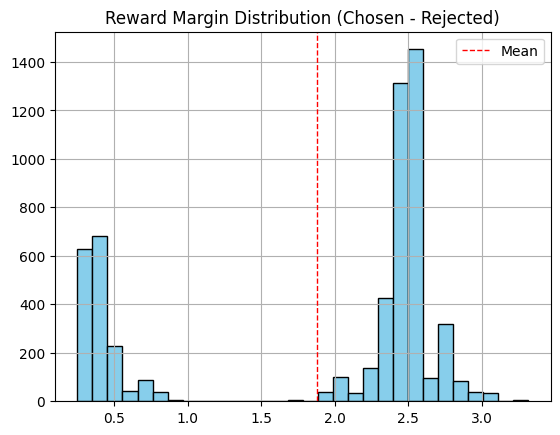

In [5]:
# Sanity check
import pandas as pd
import matplotlib.pyplot as plt

def analyze_margins(data_path):
    with open(data_path, 'r') as f:
        data = json.load(f)
    
    margins = [item['margin'] for item in data]
    df = pd.DataFrame(margins, columns=['margin'])
    
    print(f"Total pairs: {len(df)}")
    print(f"Mean Margin: {df['margin'].mean():.2f}")
    
    df['margin'].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title("Reward Margin Distribution (Chosen - Rejected)")
    plt.axvline(df['margin'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
    plt.legend()
    plt.show()

analyze_margins(PREFERENCE_DATASET_PATH)

# Direct Preference Optimization (DPO) Training

In [2]:
print("Loading previously generated preference data...")
with open(PREFERENCE_DATASET_PATH, 'r', encoding='utf-8') as f:
    pref_data = json.load(f)

dpo_dataset = Dataset.from_list(pref_data)
print(f"Successfully loaded {len(dpo_dataset)} preference pairs into HF Dataset!")

Loading previously generated preference data...
Successfully loaded 5812 preference pairs into HF Dataset!


In [3]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

print("Loading Models for DPO...")
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID, 
    quantization_config=bnb_config, 
    device_map="auto",
    attn_implementation="flash_attention_2" 
)

model = PeftModel.from_pretrained(base_model, SFT_ADAPTER_PATH, is_trainable=True)
# 🚀 USING DPOCONFIG FOR LATEST TRL VERSION
dpo_args = DPOConfig(
    output_dir="/workspace/qwen-chart-dpo",
    
    # 5090 VRAM Optimization
    per_device_train_batch_size=1, 
    gradient_accumulation_steps=8,
    
    learning_rate=5e-5, 
    lr_scheduler_type="cosine",
    save_strategy="epoch",
    logging_steps=10,
    num_train_epochs=2,
    bf16=True,
    optim="paged_adamw_32bit",
    report_to="none",
    gradient_checkpointing=True,
    remove_unused_columns=False,
    
    # DPO-Specific Parameters
    beta=0.05,
    loss_type="sigmoid",
    
    # max_prompt_length is removed in newest TRL. 
    # max_length=2400 easily fits your known max sequence of 1861 tokens!
    max_length=2400,        
)

# DPOTrainer is now much cleaner
dpo_trainer = DPOTrainer(
    model=model,
    args=dpo_args,
    train_dataset=dpo_dataset,
    processing_class=tokenizer
)

print("Starting DPO Training on RTX 5090...")
dpo_trainer.train()

dpo_trainer.model.save_pretrained("/workspace/qwen-chart-dpo-final")
tokenizer.save_pretrained("/workspace/qwen-chart-dpo-final")
print("DPO Alignment Complete! Final adapters saved.")

Loading Models for DPO...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/5812 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5812 [00:00<?, ? examples/s]

[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+chosen. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+rejected. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+chosen. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized prompt and the start of tokenized prompt+chosen. This may be due to unexpected tokenizer behavior, whitespace issues, or special token handling. Verify that the tokenizer is processing text consistently.
[RANK 0] Mismatch between tokenized pr

Starting DPO Training on RTX 5090...


Step,Training Loss
10,0.713566
20,0.675086
30,0.787198
40,0.655630
50,0.763377
60,0.727557
70,0.648565
80,0.656093
90,0.823265
100,0.755254


DPO Alignment Complete! Final adapters saved.


# DPO Generation

In [ ]:
import os
import json
import torch
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL_ID = "Qwen/Qwen2.5-3B-Instruct" 
DPO_ADAPTER_PATH = "/workspace/qwen-chart-dpo-final" 
CACHE_FILE = "grounding_cache.json"

FILES_TO_PROCESS = {
    "test_1_wo_spec.json" : "test_1_with_DPO_rationales.json",
    "test_2_wo_spec.json" : "test_2_with_DPO_rationales.json"
}

MAX_DESC_WORDS = 50
BATCH_SIZE = 16  # 🚀 THE FIX: Process 16 charts simultaneously!

def generate_dpo_rationales():
    print(f"Loading DPO Aligned Model (Batch Size: {BATCH_SIZE})...")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
    
    # 🚀 THE FIX: Batch generation requires left-padding
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left" 

    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, 
        quantization_config=bnb_config, 
        device_map="auto",
        attn_implementation="flash_attention_2"  # 🚀 THE FIX: Massive speedup for 5090
    )
    model = PeftModel.from_pretrained(base_model, DPO_ADAPTER_PATH)
    model.eval()

    cache = json.load(open(CACHE_FILE, 'r', encoding='utf-8'))

    for in_f, out_f in FILES_TO_PROCESS.items():
        if not os.path.exists(in_f):
            print(f"Skipping {in_f}, not found.")
            continue

        data = json.load(open(in_f, 'r', encoding='utf-8'))
        
        # Pre-filter valid data to make chunking cleaner
        valid_items = []
        for item in data:
            img_path = item.get("local_image_path", "").replace("\\\\", "/").replace("\\", "/")
            if img_path in cache and cache[img_path].get("deplot_table") and cache[img_path].get("vega_lite_spec"):
                item["img_path"] = img_path
                valid_items.append(item)

        results = []

        # 🚀 THE FIX: Process in chunks
        for i in tqdm(range(0, len(valid_items), BATCH_SIZE), desc=f"Processing {in_f}"):
            batch = valid_items[i : i + BATCH_SIZE]
            prompts = []

            for item in batch:
                table = cache[item["img_path"]]["deplot_table"]
                spec  = cache[item["img_path"]]["vega_lite_spec"]
                desc  = item.get("title_description", "")
                
                if desc:
                    words = desc.split()
                    if len(words) > MAX_DESC_WORDS:
                        desc = " ".join(words[:MAX_DESC_WORDS]) + "..."
                title_block = f"Chart Description:\n{desc}\n\n" if desc else ""

                user_content = (
                    f"{title_block}"
                    f"Claim: {item['claim']}\n\n"
                    f"Data Table:\n{table}\n\n"
                    f"Visual Spec:\n{spec}\n\n"
                    f"Verify if the claim is supported by the chart data. "
                    f"Think through the evidence first, then state your verdict. "
                    f"End your response with exactly 'Verdict: SUPPORTED' or 'Verdict: REFUTED'."
                )

                formatted_prompt = tokenizer.apply_chat_template(
                    [{"role": "user", "content": user_content}],
                    tokenize=False, add_generation_prompt=True
                )
                prompts.append(formatted_prompt)

            # Tokenize the whole batch at once
            inputs = tokenizer(prompts, return_tensors="pt", padding=True).to("cuda")

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=256,
                    do_sample=False,        
                    repetition_penalty=1.05,
                    pad_token_id=tokenizer.eos_token_id
                )

            # Slice out the prompt lengths and decode
            input_lengths = inputs.input_ids.shape[1]
            generated_texts = tokenizer.batch_decode(outputs[:, input_lengths:], skip_special_tokens=True)

            for item, gen_text in zip(batch, generated_texts):
                item["generated_rationale"] = gen_text
                results.append(item)

        with open(out_f, 'w', encoding='utf-8') as f:
            json.dump(results, f, indent=4)
        print(f"Saved {len(results)} items to {out_f}")

    del model, base_model
    torch.cuda.empty_cache()

generate_dpo_rationales()

Loading DPO Aligned Model (Batch Size: 16)...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Processing test_1_wo_spec.json:   0%|          | 0/59 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
